In [7]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), _ = mnist.load_data()

In [8]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

In [10]:
model1 = keras.Sequential([
 layers.Dense(512, activation="relu"),
 layers.Dense(10, activation="softmax")
])
model1.compile(optimizer=keras.optimizers.RMSprop(1.),
 loss="sparse_categorical_crossentropy",
 metrics=["accuracy"])
history1 = model1.fit(train_images, train_labels, epochs=10, batch_size=128,validation_split=0.2)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3849 - loss: 2630.2280 - val_accuracy: 0.2004 - val_loss: 2.1713
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1820 - loss: 2.9252 - val_accuracy: 0.2151 - val_loss: 2.2138
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1752 - loss: 2.6949 - val_accuracy: 0.1558 - val_loss: 2.3191
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1649 - loss: 2.5585 - val_accuracy: 0.2133 - val_loss: 2.1616
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1949 - loss: 2.5460 - val_accuracy: 0.1903 - val_loss: 2.2844
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2178 - loss: 2.4797 - val_accuracy: 0.1774 - val_loss: 2.2616
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.1939 - loss: 2.7226 - val_accuracy: 0.1818 - val_loss: 7.5012
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2168 - loss: 2.4603 - val_accu

In [11]:
model2 = keras.Sequential([
 layers.Dense(512, activation="relu"),
 layers.Dense(10, activation="softmax")
])
model2.compile(optimizer=keras.optimizers.RMSprop(1e-2),
 loss="sparse_categorical_crossentropy",
 metrics=["accuracy"])
history2 = model2.fit(train_images, train_labels,
 epochs=10,
 batch_size=128,
 validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8414 - loss: 0.7294 - val_accuracy: 0.9566 - val_loss: 0.1489
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9642 - loss: 0.1249 - val_accuracy: 0.9656 - val_loss: 0.1364
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9756 - loss: 0.0897 - val_accuracy: 0.9704 - val_loss: 0.1356
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9793 - loss: 0.0750 - val_accuracy: 0.9660 - val_loss: 0.1773
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9836 - loss: 0.0627 - val_accuracy: 0.9620 - val_loss: 0.1927
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9852 - loss: 0.0575 - val_accuracy: 0.9717 - val_loss: 0.1736
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9877 - loss: 0.0507 - val_accuracy: 0.9725 - val_loss: 0.1760
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9896 - loss: 0.0403 - val_accur

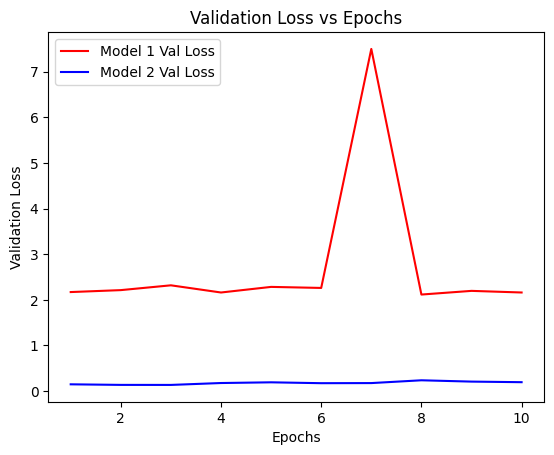

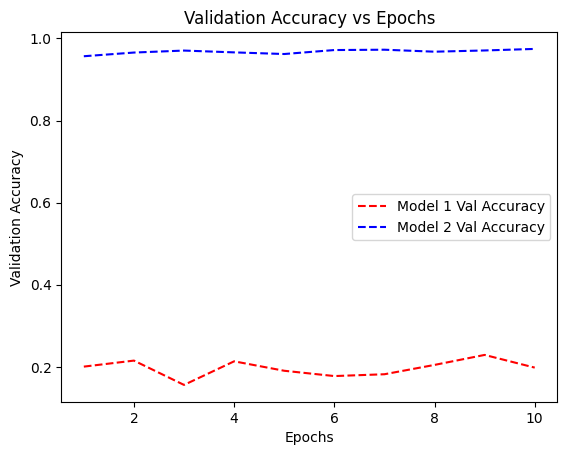

In [15]:
import matplotlib.pyplot as plt

# extract metrics
val_loss_1 = history1.history['val_loss']
val_loss_2 = history2.history['val_loss']
val_acc_1  = history1.history['val_accuracy']
val_acc_2  = history2.history['val_accuracy']

epochs = range(1, len(val_loss_1) + 1)

# ===== Graph 1: Validation Loss =====
plt.figure()
plt.plot(epochs, val_loss_1, 'r-', label='Model 1 Val Loss')
plt.plot(epochs, val_loss_2, 'b-', label='Model 2 Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Validation Loss vs Epochs')
plt.legend()
plt.show()

# ===== Graph 2: Validation Accuracy =====
plt.figure()
plt.plot(epochs, val_acc_1, 'r--', label='Model 1 Val Accuracy')
plt.plot(epochs, val_acc_2, 'b--', label='Model 2 Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs Epochs')
plt.legend()
plt.show()